In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from regimesense.data.fetcher       import load_data_from_config
from regimesense.features.regime_features import build_feature_matrix, normalize_features
from regimesense.regime.hmm_classifier   import RegimeClassifier
from regimesense.portfolio.allocator     import MetaAllocator, performance_metrics

plt.style.use('seaborn-v0_8-whitegrid')

# ── Load and split ──────────────────────────────────────────────────
df       = load_data_from_config()
features = build_feature_matrix(df)
normed   = normalize_features(features)

TRAIN_END = "2020-12-31"
TEST_START = "2021-01-01"

# Split features for train/test
features_train = normed[normed.index <= TRAIN_END]
features_test  = normed[normed.index >= TEST_START]

# ── Train HMM on training data ONLY ────────────────────────────────
clf = RegimeClassifier(n_states=4, n_iter=200, random_state=42)
clf.fit(features_train)

# ── Predict on BOTH periods (but report only test) ──────────────────
regimes_full = clf.predict(normed)          # all dates
regimes_test = regimes_full[regimes_full.index >= TEST_START]

# ── Run allocator ───────────────────────────────────────────────────
allocator = MetaAllocator()
results_full = allocator.compute_portfolio_returns(df, regimes_full)
results_test = results_full[results_full.index >= TEST_START]

print(f"Training period : {features_train.index[0].date()} → {features_train.index[-1].date()}")
print(f"Test period     : {features_test.index[0].date()}  → {features_test.index[-1].date()}")
print(f"Test days       : {len(results_test)}")

2026-03-20 19:55:30,813  INFO  Fetching SPY from 2005-01-01 to 2024-12-31 ...
/workspaces/RegimeSense/.venv/lib/python3.12/site-packages/yfinance/scrapers/history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
2026-03-20 19:55:31,263  INFO  Fetched 5032 trading days for SPY.
2026-03-20 19:55:31,263  INFO  Computing regime features ...
2026-03-20 19:55:32,808  INFO  Feature matrix: 4972 rows (60 dropped for rolling warm-up).
2026-03-20 19:55:32,813  INFO  Training HMM: 4 states, 3968 observations, 5 features ...
2026-03-20 19:55:33,797  INFO  HMM training complete.
2026-03-20 19:55:33,799  INFO    Converged: True
2026-03-20 19:55:33,805  INFO    Log-likelihood: -20922.36
2026-03-20 19:55:33,806  INFO  
Learned feature means per state (normalized):
2026-03-20 19:55:33,811  INFO     realized_vol  autocorr_5d  rolling_sharpe  skewness  volume_momentum
0        -0.650       -0

Training period : 2005-03-31 → 2020-12-31
Test period     : 2021-01-04  → 2024-12-30
Test days       : 1004


In [2]:
results_train = results_full[results_full.index <= TRAIN_END]

strategies = {
    "Momentum":        "return_momentum",
    "Mean Reversion":  "return_mean_reversion",
    "Trend Following": "return_trend_following",
    "Defensive":       "return_defensive",
    "RegimeSense":     "portfolio_return",
}

# SPY buy-and-hold benchmark
spy_ret  = df["Close"].pct_change().dropna()
spy_train = spy_ret[spy_ret.index <= TRAIN_END]
spy_test  = spy_ret[spy_ret.index >= TEST_START]

print("=" * 72)
print(f"{'Strategy':<18} {'IS Sharpe':>9} {'IS Ret':>8} | "
      f"{'OOS Sharpe':>10} {'OOS Ret':>8} {'OOS MaxDD':>10}")
print("=" * 72)

for label, col in strategies.items():
    is_m  = performance_metrics(results_train[col])
    oos_m = performance_metrics(results_test[col])
    print(f"{label:<18} {is_m['sharpe']:>9.3f} {is_m['ann_return']:>7.1%} | "
          f"{oos_m['sharpe']:>10.3f} {oos_m['ann_return']:>7.1%} "
          f"{oos_m['max_drawdown']:>10.1%}")

# SPY benchmark row
is_spy  = performance_metrics(spy_train)
oos_spy = performance_metrics(spy_test)
print("-" * 72)
print(f"{'SPY Buy-Hold':<18} {is_spy['sharpe']:>9.3f} {is_spy['ann_return']:>7.1%} | "
      f"{oos_spy['sharpe']:>10.3f} {oos_spy['ann_return']:>7.1%} "
      f"{oos_spy['max_drawdown']:>10.1%}")
print("=" * 72)
print("\nTarget: OOS Sharpe > SPY OOS Sharpe, OOS MaxDD smaller than SPY")

Strategy           IS Sharpe   IS Ret | OOS Sharpe  OOS Ret  OOS MaxDD
Momentum               0.570    8.5% |      0.974   12.6%     -18.2%
Mean Reversion         0.411    5.3% |      0.584    5.6%     -14.0%
Trend Following        0.620    8.5% |      1.243   15.0%     -13.2%
Defensive              0.571    7.0% |      0.690    9.0%     -29.1%
RegimeSense            0.704    6.4% |      1.160   10.8%     -16.0%
------------------------------------------------------------------------
SPY Buy-Hold           0.562   11.0% |      0.859   14.2%     -24.5%

Target: OOS Sharpe > SPY OOS Sharpe, OOS MaxDD smaller than SPY


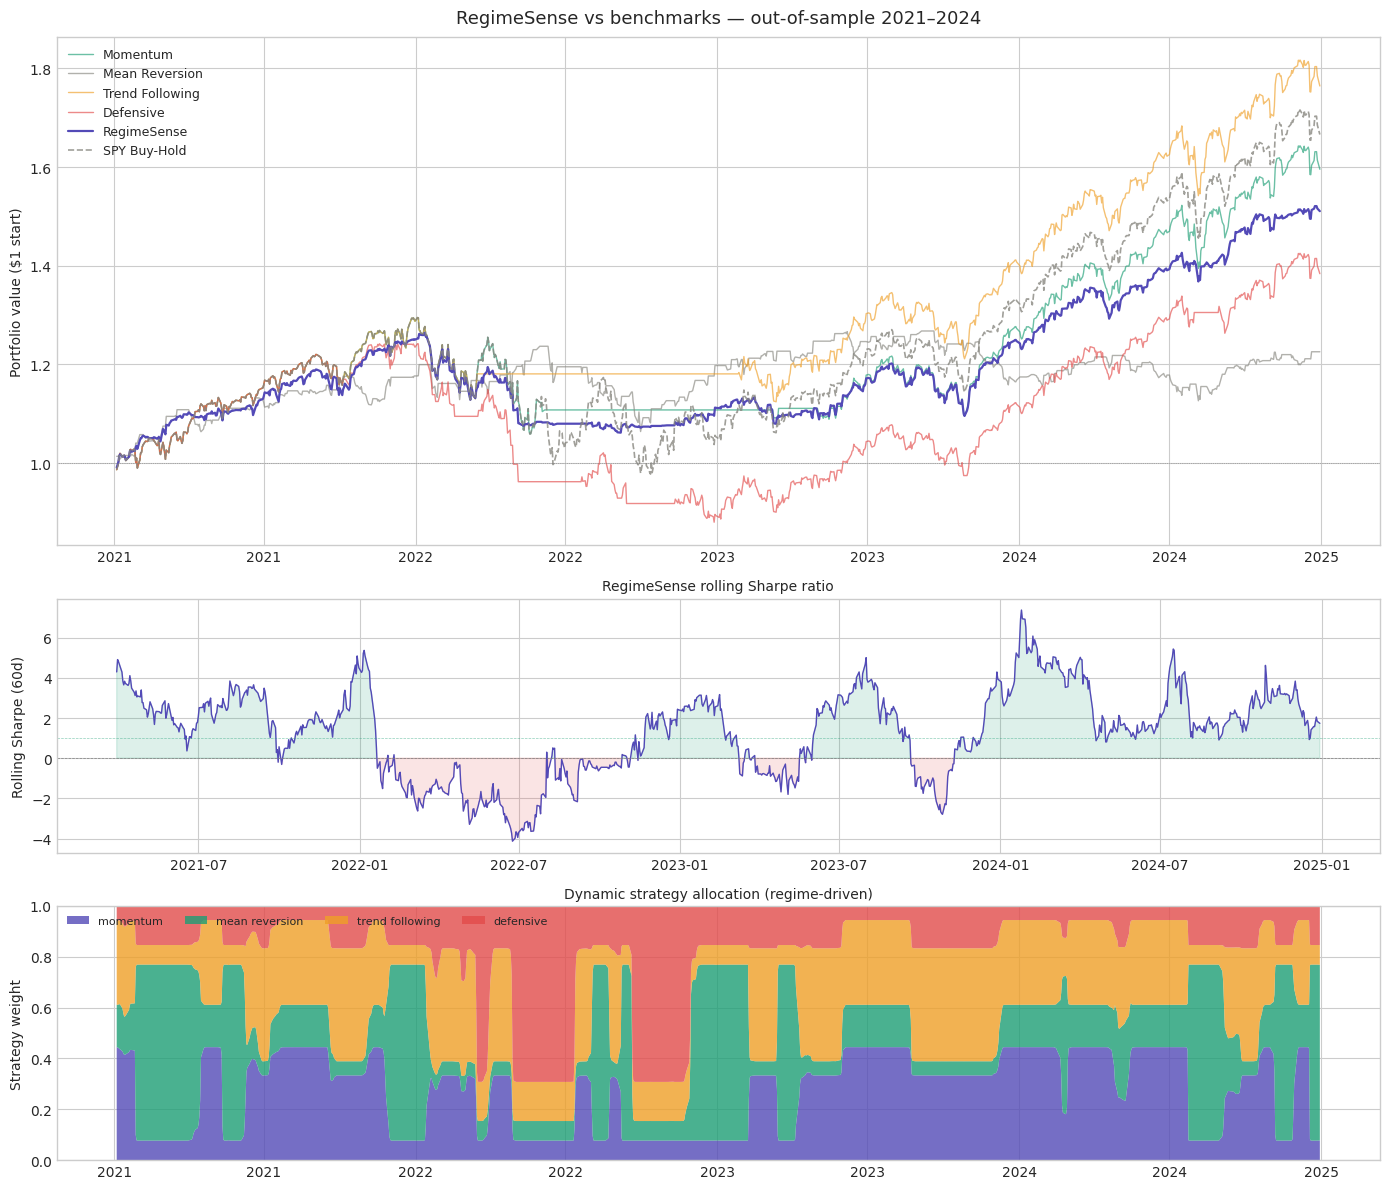

Saved → logs/backtest_results.png


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                         gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

# Colour map
COLORS = {
    "RegimeSense":     "#534AB7",
    "SPY Buy-Hold":    "#888780",
    "Momentum":        "#1D9E75",
    "Trend Following": "#EF9F27",
    "Defensive":       "#E24B4A",
}

# ── Panel 1: Cumulative equity curves ─────────────────────────────
ax = axes[0]
ax.set_title("RegimeSense vs benchmarks — out-of-sample 2021–2024",
             fontsize=13, pad=10)

# Plot each strategy equity curve on OOS data
for label, col in strategies.items():
    cum = (1 + results_test[col]).cumprod()
    ax.plot(cum.index, cum,
            label=label,
            color=COLORS.get(label, "#888780"),
            linewidth=1.6 if label == "RegimeSense" else 1.0,
            alpha=1.0 if label == "RegimeSense" else 0.65)

# SPY buy-hold curve
spy_oos_cum = (1 + spy_test.reindex(results_test.index).fillna(0)).cumprod()
ax.plot(spy_oos_cum.index, spy_oos_cum,
        label="SPY Buy-Hold", color=COLORS["SPY Buy-Hold"],
        linewidth=1.2, linestyle="--", alpha=0.8)

ax.axhline(1.0, color="gray", linewidth=0.5, linestyle=":")
ax.set_ylabel("Portfolio value ($1 start)")
ax.legend(fontsize=9, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Panel 2: Rolling 60-day Sharpe ────────────────────────────────
ax2 = axes[1]
roll_sharpe = (results_test["portfolio_return"]
               .rolling(60).mean()
               / results_test["portfolio_return"].rolling(60).std()
               * np.sqrt(252))
ax2.plot(roll_sharpe.index, roll_sharpe,
         color="#534AB7", linewidth=1)
ax2.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax2.axhline(1, color="#1D9E75", linewidth=0.5, linestyle="--", alpha=0.5)
ax2.set_ylabel("Rolling Sharpe (60d)")
ax2.set_title("RegimeSense rolling Sharpe ratio", fontsize=10)
ax2.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=roll_sharpe > 0, alpha=0.15, color="#1D9E75")
ax2.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=roll_sharpe < 0, alpha=0.15, color="#E24B4A")

# ── Panel 3: Strategy weight allocation over time ──────────────────
ax3 = axes[2]
weight_cols  = [c for c in results_test.columns if c.startswith("weight_")]
weight_names = [c.replace("weight_","").replace("_"," ") for c in weight_cols]
weight_colors= ["#534AB7","#1D9E75","#EF9F27","#E24B4A"]

ax3.stackplot(results_test.index,
              [results_test[c] for c in weight_cols],
              labels=weight_names,
              colors=weight_colors,
              alpha=0.8)
ax3.set_ylabel("Strategy weight")
ax3.set_ylim(0, 1)
ax3.set_title("Dynamic strategy allocation (regime-driven)", fontsize=10)
ax3.legend(fontsize=8, loc="upper left", ncol=4)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../logs/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → logs/backtest_results.png")

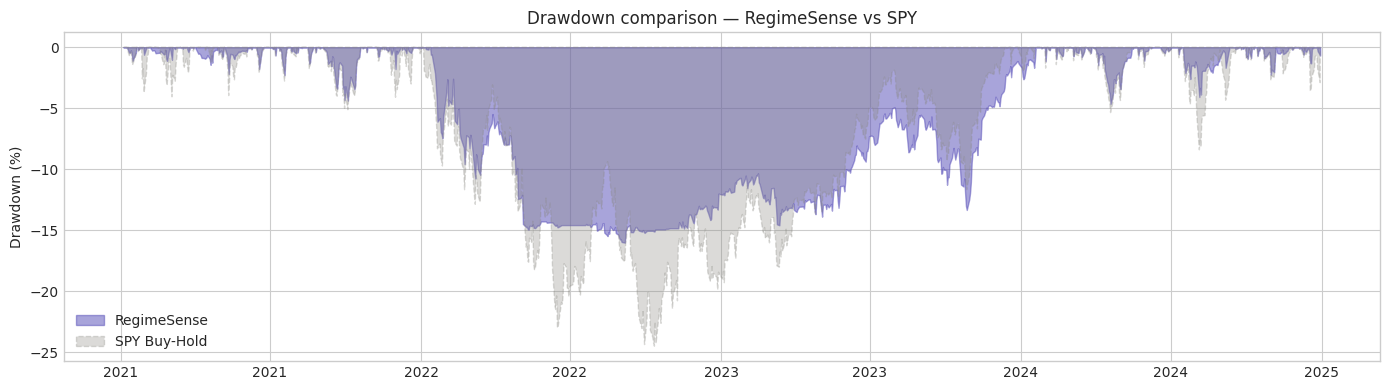


RegimeSense max DD : -16.0%
SPY max DD         : -24.5%


In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

def compute_drawdown(returns):
    cum   = (1 + returns).cumprod()
    peak  = cum.cummax()
    return (cum - peak) / peak

dd_portfolio = compute_drawdown(results_test["portfolio_return"])
dd_spy       = compute_drawdown(spy_test.reindex(results_test.index).fillna(0))

ax.fill_between(dd_portfolio.index, dd_portfolio * 100, 0,
                alpha=0.5, color="#534AB7", label="RegimeSense")
ax.fill_between(dd_spy.index, dd_spy * 100, 0,
                alpha=0.3, color="#888780", label="SPY Buy-Hold",
                linestyle="--")

ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown comparison — RegimeSense vs SPY", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../logs/drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRegimeSense max DD : {dd_portfolio.min()*100:.1f}%")
print(f"SPY max DD         : {dd_spy.min()*100:.1f}%")

In [5]:
# This answers: "does the crisis regime actually match real crisis periods?"
crisis_days = regimes_full[regimes_full["regime_label"] == "crisis"].index

print("Crisis periods detected by HMM:")
print("(Should include: 2020 COVID crash, 2022 bear market, 2008 GFC)\n")

# Group consecutive crisis days into periods
from itertools import groupby
from operator import itemgetter

crisis_int = sorted([d.toordinal() for d in crisis_days])
periods = []
for k, g in groupby(enumerate(crisis_int), lambda x: x[1]-x[0]):
    group = list(map(itemgetter(1), g))
    start = pd.Timestamp.fromordinal(group[0])
    end   = pd.Timestamp.fromordinal(group[-1])
    days  = len(group)
    if days >= 5:   # only show periods lasting at least 1 week
        periods.append((start, end, days))

for start, end, days in sorted(periods):
    print(f"  {start.strftime('%Y-%m-%d')} → {end.strftime('%Y-%m-%d')}  "
          f"({days} trading days)")

Crisis periods detected by HMM:
(Should include: 2020 COVID crash, 2022 bear market, 2008 GFC)

  2007-07-30 → 2007-08-03  (5 trading days)
  2007-08-06 → 2007-08-10  (5 trading days)
  2007-08-13 → 2007-08-17  (5 trading days)
  2007-08-20 → 2007-08-24  (5 trading days)
  2007-08-27 → 2007-08-31  (5 trading days)
  2007-11-26 → 2007-11-30  (5 trading days)
  2007-12-03 → 2007-12-07  (5 trading days)
  2007-12-10 → 2007-12-14  (5 trading days)
  2007-12-17 → 2007-12-21  (5 trading days)
  2008-03-24 → 2008-03-28  (5 trading days)
  2008-03-31 → 2008-04-04  (5 trading days)
  2008-04-07 → 2008-04-11  (5 trading days)
  2008-09-08 → 2008-09-12  (5 trading days)
  2008-09-15 → 2008-09-19  (5 trading days)
  2008-09-22 → 2008-09-26  (5 trading days)
  2008-09-29 → 2008-10-03  (5 trading days)
  2008-10-06 → 2008-10-10  (5 trading days)
  2008-10-13 → 2008-10-17  (5 trading days)
  2008-10-20 → 2008-10-24  (5 trading days)
  2008-10-27 → 2008-10-31  (5 trading days)
  2008-11-03 → 2008-11-0